# 📘 Datathon – Fase 5 (FIAP)
## Projeto: IA aplicada a Recrutamento & Seleção (Decision)

**Aluno:** Matheus Amaral de Oliveira  
**Curso / Trilha:** Pós-Tech Data Analytics – FIAP  
**Entrega:** Datathon – Fase 5  
**Tema:** Otimização do processo de recrutamento (bodyshop/Decision) com IA/ML

---


### 🎯 Objetivo do Projeto
- Endereçar dores do processo de R&S (padronização de entrevistas, medição de engajamento, agilidade no match).
- Construir um pipeline de **ETL + EDA + Modelagem** com rastreabilidade e documentação clara.
- Preparar base para **MVP em Streamlit** (quando aplicável) e **storytelling** para a banca.

### 🗂️ Fontes de Dados (visão geral)
- `vagas.json` – metadados da vaga (informações básicas, perfil, benefícios).
- `prospects.json` – candidaturas/prospecções por vaga.
- `applicants.json` – dados detalhados dos candidatos (inclui CV, idiomas, formações).

### 🧭 Roteiro (Storytelling)
1. **Contexto e objetivos**  
2. **Carga & ETL** (JSON → DataFrame, normalização, limpeza)  
3. **EDA** (qualidade, nulos, distribuições, correlações)  
4. **Feature engineering** (textos, categóricas, numéricas)  
5. **Modelagem** (baseline → refinamento)  
6. **Avaliação e métricas**  
7. **Produto (MVP/Streamlit)**  
8. **Conclusões & Próximos Passos**  

---


### 📎 Guia de Leitura
- Antes de **cada bloco de código**, há uma linha explicando **o que o bloco faz**.  
- Comentários são objetivos, em português, e seguem boas práticas de engenharia de dados.  
- Se houver gráficos ou artefatos, serão contextualizados no texto.  
---

#### Iniciando o Datathon



#### 🔎 Importação de bibliotecas
- Importa bibliotecas: `json
import pandas as pd
from pandas import json_normalize`
- **Achata/expande** campos aninhados (dict/list) com `json_normalize`.

In [1]:
import json
import pandas as pd
from pandas import json_normalize
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

# Vagas

#### 🔎 Carregamento de informações sobre Vagas.json
- Carrega dados em **JSON** para `DataFrame`/dicionário.
- **Achata/expande** campos aninhados (dict/list) com `json_normalize`.
- **Explode** listas → múltiplas linhas por item.

In [2]:
def expand_like_power_query(df, max_loops=3):
    """
    Expande automaticamente colunas dict (registros) e list (listas) em até max_loops iterações.
    Não aplica prefixo (igual você tirou no PQ).
    """
    df = df.copy()
    for _ in range(max_loops):
        changed = False

        # 1) expandir dict -> colunas
        dict_cols = [c for c in df.columns if df[c].apply(lambda x: isinstance(x, dict)).any()]
        for c in dict_cols:
            expanded = json_normalize(df[c])
            df = pd.concat([df.drop(columns=[c]), expanded], axis=1)
            changed = True

        # 2) expandir list -> linhas (explode) e depois normalizar se item for dict
        list_cols = [c for c in df.columns if df[c].apply(lambda x: isinstance(x, list)).any()]
        for c in list_cols:
            df = df.explode(c, ignore_index=True)
            # se itens da lista são dict, expandimos
            if df[c].apply(lambda x: isinstance(x, dict)).any():
                expanded = json_normalize(df[c])
                df = pd.concat([df.drop(columns=[c]), expanded], axis=1)
            else:
                # se não for dict (ex.: lista de strings), mantém como está
                pass
            changed = True

        if not changed:
            break
    return df
# Exemplo de uso com vagas.json:
with open("/content/vagas.json", "r", encoding="utf-8") as f:
    raw = json.load(f)

base = pd.DataFrame([{"id_vaga": k, **v} for k, v in raw.items()])
df_flat = expand_like_power_query(base)

print(df_flat.shape)

(14081, 45)


#### 🔎Convertendo os tipos de dados da coluna
- **Converte tipos** (datas, números, booleanos).

In [3]:
# Partimos do df_flat (resultado do expand_like_power_query)
df = df_flat.copy()

# 1) Renomear colunas problemáticas (se existirem)
rename_map = {
    "nivel profissional": "nivel_profissional",
    "data_requicisao": "data_requisicao",   # ajuste do nome
}
df.rename(columns={k:v for k,v in rename_map.items() if k in df.columns}, inplace=True)

# 2) Datas (formato do dataset é DD-MM-AAAA)
date_cols = [c for c in ["data_requisicao", "data_inicial", "data_final"] if c in df.columns]
for c in date_cols:
    df[c] = pd.to_datetime(df[c], dayfirst=True, errors="coerce")

# 3) Moedas (R$, pontos de milhar e vírgula decimal)
money_cols = [c for c in ["valor_venda", "valor_compra_1", "valor_compra_2"] if c in df.columns]
def _to_money(series: pd.Series) -> pd.Series:
    s = series.astype(str)
    s = s.str.replace(r"[^0-9,.\-]", "", regex=True)   # remove R$, espaços, etc.
    s = s.str.replace(".", "", regex=False)            # remove milhar
    s = s.str.replace(",", ".", regex=False)           # vírgula -> ponto
    return pd.to_numeric(s, errors="coerce")
for c in money_cols:
    df[c] = _to_money(df[c])

# 4) Booleanos (sim/não/true/false/1/0)
bool_cols = [c for c in ["vaga_sap", "vaga_especifica_para_pcd", "viagens_requeridas"] if c in df.columns]
_true = {"sim","s","true","1","yes"}
_false = {"nao","não","n","false","0","no"}
def _to_bool(series: pd.Series) -> pd.Series:
    s = series.astype(str).str.strip().str.lower()
    out = s.map(lambda x: True if x in _true else (False if x in _false else pd.NA))
    return out.astype("boolean")
for c in bool_cols:
    df[c] = _to_bool(df[c])

# 5) Possíveis numéricos adicionais (tenta converter, sem forçar)
maybe_num = [c for c in ["limite_esperado_para_contratacao", "faixa_etaria"] if c in df.columns]
for c in maybe_num:
    df[c] = pd.to_numeric(df[c], errors="ignore")

/tmp/ipython-input-3481823588.py:41: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df[c] = pd.to_numeric(df[c], errors="ignore")


In [4]:
df_flat = df

In [5]:
df_flat.shape

(14081, 45)

# Prospects

In [6]:
# --- reuso da sua função ---
def expand_like_power_query(df, max_loops=3):
    df = df.copy()
    for _ in range(max_loops):
        changed = False
        dict_cols = [c for c in df.columns if df[c].apply(lambda x: isinstance(x, dict)).any()]
        for c in dict_cols:
            expanded = json_normalize(df[c])
            df = pd.concat([df.drop(columns=[c]), expanded], axis=1)
            changed = True
        list_cols = [c for c in df.columns if df[c].apply(lambda x: isinstance(x, list)).any()]
        for c in list_cols:
            df = df.explode(c, ignore_index=True)
            if df[c].apply(lambda x: isinstance(x, dict)).any():
                expanded = json_normalize(df[c])
                df = pd.concat([df.drop(columns=[c]), expanded], axis=1)
            changed = True
        if not changed:
            break
    return df

# --- carregar prospects.json (key = id_vaga) ---
with open("/content/prospects.json", "r", encoding="utf-8") as f:
    raw_p = json.load(f)

# Alguns dumps vêm como { "10976": [ {...}, {...} ], ... } ou { "10976": {"prospects":[...]}, ... }
rows = []
for k, v in raw_p.items():
    # garante uma coluna-lista consistente
    if isinstance(v, list):
        rows.append({"id_vaga": k, "prospects": v})
    else:
        rows.append({"id_vaga": k, **v})

base_p = pd.DataFrame(rows)

# --- expandir/achatar como no Power Query ---
df_prospects = expand_like_power_query(base_p)

print(df_prospects.shape)

(56702, 10)


In [7]:
# Partindo do DataFrame de prospects já carregado (ex.: df_prospects)
df = df_prospects.copy()

# 1) Corrigir o nome da coluna com typo
if "situacao_candidado" in df.columns and "situacao_candidato" not in df.columns:
    df.rename(columns={"situacao_candidado": "situacao_candidato"}, inplace=True)

# 2) Padronizar texto da situação
if "situacao_candidato" in df.columns:
    df["situacao_candidato"] = df["situacao_candidato"].astype(str).str.strip()

# 3) Renomear 'codigo' -> 'id_candidato' (se fizer sentido no seu dataset)
if "codigo" in df.columns and "id_candidato" not in df.columns:
    df.rename(columns={"codigo": "id_candidato"}, inplace=True)

# 4) Converter datas (DD-MM-AAAA)
for c in ["data_candidatura", "ultima_atualizacao"]:
    if c in df.columns:
        df[c] = pd.to_datetime(df[c], dayfirst=True, errors="coerce")

# 5) Garantir IDs como string
for c in ["id_vaga", "id_candidato"]:
    if c in df.columns:
        df[c] = df[c].astype(str)

# 6) Limpar 'recrutador' (opcional)
if "recrutador" in df.columns:
    df["recrutador"] = df["recrutador"].astype(str).str.strip().str.title()

# Conferir tipos
df.dtypes

,0
id_vaga,object
titulo,object
modalidade,object
nome,object
id_candidato,object
situacao_candidato,object
data_candidatura,datetime64[ns]
ultima_atualizacao,datetime64[ns]
comentario,object
recrutador,object


In [8]:
df_prospects = df

In [9]:
df_prospects.shape

(56702, 10)

# Applicants

In [10]:
# --- reuso da função genérica ---
def expand_like_power_query(df, max_loops=3):
    df = df.copy()
    for _ in range(max_loops):
        changed = False
        dict_cols = [c for c in df.columns if df[c].apply(lambda x: isinstance(x, dict)).any()]
        for c in dict_cols:
            expanded = json_normalize(df[c])
            df = pd.concat([df.drop(columns=[c]), expanded], axis=1)
            changed = True
        list_cols = [c for c in df.columns if df[c].apply(lambda x: isinstance(x, list)).any()]
        for c in list_cols:
            df = df.explode(c, ignore_index=True)
            if df[c].apply(lambda x: isinstance(x, dict)).any():
                expanded = json_normalize(df[c])
                df = pd.concat([df.drop(columns=[c]), expanded], axis=1)
            changed = True
        if not changed:
            break
    return df

# --- 1) Carregar applicants.json ---
with open("/content/applicants.json", "r", encoding="utf-8") as f:
    raw_a = json.load(f)

# Pode vir como { "31000": {...}, "31001": {...} }  → preservamos a chave como id
if isinstance(raw_a, dict):
    base_a = pd.DataFrame([{"id_candidato": k, **v} for k, v in raw_a.items()])
elif isinstance(raw_a, list):
    base_a = pd.DataFrame(raw_a)
else:
    raise ValueError("Formato inesperado em applicants.json")

# --- 2) Achatar/expandir (dict/list) automaticamente ---
df_applicants = expand_like_power_query(base_a)

# --- 3) Padronizações mínimas e tipos úteis ---
# garantir id_candidato como string (se existir outra coluna equivalente, renomeie)
if "id_candidato" in df_applicants.columns:
    df_applicants["id_candidato"] = df_applicants["id_candidato"].astype(str)
elif "_key" in df_applicants.columns:
    df_applicants.rename(columns={"_key": "id_candidato"}, inplace=True)
    df_applicants["id_candidato"] = df_applicants["id_candidato"].astype(str)

# datas comuns (se existirem nessas seções)
for c in [ "pess_data_aceite", "prof_data_inicio", "prof_data_fim" ]:
    if c in df_applicants.columns:
        df_applicants[c] = pd.to_datetime(df_applicants[c], dayfirst=True, errors="coerce")

# níveis/idiomas (mantém como texto por enquanto)
for c in ["form_nivel_academico","form_nivel_ingles","form_nivel_espanhol"]:
    if c in df_applicants.columns:
        df_applicants[c] = df_applicants[c].astype(str).str.strip()

# --- 4) Inspeção rápida ---
print(df_applicants.shape)

(42482, 58)


In [11]:
# Partimos de df_applicants já carregado/expandido
df = df_applicants.copy()

import pandas as pd

# 1) Unificar colunas duplicadas: mantém a 1ª e preenche com a 1ª não-nula das demais
dups = [c for c in df.columns if df.columns.tolist().count(c) > 1]
for col in sorted(set(dups), key=lambda x: df.columns.tolist().index(x)):
    same = [c for c in df.columns if c == col]
    # combina: pega o 1º valor não-nulo por linha
    df[same[0]] = df[same].bfill(axis=1).iloc[:, 0]
    # dropa as demais ocorrências
    df.drop(columns=same[1:], inplace=True)

# 2) Garantir ID como string
if "id_candidato" in df.columns:
    df["id_candidato"] = df["id_candidato"].astype(str).str.strip()

# 3) Normalizar datas (formato comum do dataset é DD-MM-AAAA; ajusta a lista conforme existir)
date_cols = [
    "data_criacao","data_atualizacao","data_aceite","data_nascimento",
    "data_admissao","data_ultima_promocao"
]
for c in date_cols:
    if c in df.columns:
        df[c] = pd.to_datetime(df[c], dayfirst=True, errors="coerce")

# 4) Converter PCD para boolean (sim/não/true/false/1/0)
if "pcd" in df.columns:
    true_set  = {"sim","s","true","1","yes"}
    false_set = {"nao","não","n","false","0","no"}
    s = df["pcd"].astype(str).str.strip().str.lower()
    df["pcd"] = s.map(lambda x: True if x in true_set else (False if x in false_set else pd.NA)).astype("boolean")

# 5) (Opcional) limpar espaços em textos importantes
for c in ["nome","email","email_secundario","telefone","telefone_celular","telefone_recado","titulo_profissional","area_atuacao"]:
    if c in df.columns:
        df[c] = df[c].astype(str).str.strip()

# 6) Ver resultado
print("Shape:", df.shape)

/tmp/ipython-input-3429222807.py:26: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df[c] = pd.to_datetime(df[c], dayfirst=True, errors="coerce")


Shape: (42482, 52)


/tmp/ipython-input-3429222807.py:26: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df[c] = pd.to_datetime(df[c], dayfirst=True, errors="coerce")


In [12]:
df_applicants = df

# Visualização

In [13]:
print("df_flat:", df_flat.shape)
print("df_prospects:", df_prospects.shape)
print("df_applicants:", df_applicants.shape)

df_flat: (14081, 45)
df_prospects: (56702, 10)
df_applicants: (42482, 52)


# Pyspark

In [14]:
import json
import pandas as pd
from pyspark.sql import SparkSession

# --- Funções utilitárias ---

def sanitize_cols(pdf: pd.DataFrame) -> pd.DataFrame:
    pdf = pdf.copy()
    pdf.columns = (
        pdf.columns
          .str.strip()
          .str.replace(r"\s+", "_", regex=True)
          .str.replace(r"[^\w]", "_", regex=True)
    )
    return pdf

def coerce_nested_to_string(pdf: pd.DataFrame) -> pd.DataFrame:
    """
    Para cada coluna:
      - Se houver qualquer dict/list, serializa toda a coluna como string JSON
        e tipa como pandas StringDtype (evita mix de tipos).
      - Caso contrário, mantém como está; ao final, garante que cols 'object'
        virem StringDtype para consistência, se quiser.
    """
    out = pdf.copy()
    for col in out.columns:
        s = out[col]
        # detecta qualquer dict/list
        has_nested = s.apply(lambda x: isinstance(x, (dict, list))).any()
        if has_nested:
            # serializa tudo como string (dict/list -> json; demais -> str)
            out[col] = s.map(lambda v: json.dumps(v, ensure_ascii=False) if isinstance(v, (dict, list)) else ("" if pd.isna(v) else str(v)))
            out[col] = out[col].astype("string")
        else:
            # opcional: se dtype for object, padroniza para string
            if s.dtype == "object":
                out[col] = s.astype("string")
    return out

# --- 1) Preparar os três DataFrames pandas atualizados ---
vagas_pdf = df_flat.copy()
pros_pdf  = df_prospects.copy()
apps_pdf  = df_applicants.copy()

# Sanitizar nomes (opcional, facilita SQL sem crase)
vagas_pdf = sanitize_cols(vagas_pdf)
pros_pdf  = sanitize_cols(pros_pdf)
apps_pdf  = sanitize_cols(apps_pdf)

# Uniformizar tipos para o Spark (resolve o StructType x BooleanType)
vagas_pdf = coerce_nested_to_string(vagas_pdf)
pros_pdf  = coerce_nested_to_string(pros_pdf)
apps_pdf  = coerce_nested_to_string(apps_pdf)

# (Opcional) remover colunas duplicadas, se houver
vagas_pdf = vagas_pdf.loc[:, ~vagas_pdf.columns.duplicated()]
pros_pdf  = pros_pdf.loc[:, ~pros_pdf.columns.duplicated()]
apps_pdf  = apps_pdf.loc[:, ~apps_pdf.columns.duplicated()]

# --- 2) Criar sessão Spark e converter ---
spark = SparkSession.builder.appName("DatathonDecision").getOrCreate()
spark.conf.set("spark.sql.execution.arrow.pyspark.enabled", "true")  # opcional (pode acelerar)

s_vagas      = spark.createDataFrame(vagas_pdf)
s_prospects  = spark.createDataFrame(pros_pdf)
s_applicants = spark.createDataFrame(apps_pdf)

# --- 3) Views SQL ---
s_vagas.createOrReplaceTempView("vagas")
s_prospects.createOrReplaceTempView("prospects")
s_applicants.createOrReplaceTempView("applicants")

# Sanidade
print("Pandas shapes:", vagas_pdf.shape, pros_pdf.shape, apps_pdf.shape)
spark.sql("SELECT COUNT(*) AS n FROM vagas").show()
spark.sql("SELECT COUNT(*) AS n FROM prospects").show()
spark.sql("SELECT COUNT(*) AS n FROM applicants").show()

Pandas shapes: (14081, 45) (56702, 10) (42482, 52)
+-----+
|    n|
+-----+
|14081|
+-----+

+-----+
|    n|
+-----+
|56702|
+-----+

+-----+
|    n|
+-----+
|42482|
+-----+



In [15]:
# 1) Instalar / iniciar PySpark (se já estiver rodando, pode pular a instalação)
!pip -q install pyspark==3.5.1

from pyspark.sql import SparkSession
spark = SparkSession.builder.appName("DatathonDecision").getOrCreate()

# 2) Copiar os DFs pandas atualizados
vagas_pdf = df_flat.copy()
pros_pdf  = df_prospects.copy()
apps_pdf  = df_applicants.copy()

# 2.1 Opcional: nomes de colunas sem espaços/acentos para facilitar SQL (evita usar crases)
def sanitize_cols(pdf):
    pdf = pdf.copy()
    pdf.columns = (
        pdf.columns
          .str.strip()
          .str.replace(r"\s+", "_", regex=True)
          .str.replace(r"[^\w]", "_", regex=True)
    )
    return pdf

vagas_pdf = sanitize_cols(vagas_pdf)
pros_pdf  = sanitize_cols(pros_pdf)
apps_pdf  = sanitize_cols(apps_pdf)

# 3) Converter para Spark DataFrames (schema inferido do pandas)
s_vagas      = spark.createDataFrame(vagas_pdf)
s_prospects  = spark.createDataFrame(pros_pdf)
s_applicants = spark.createDataFrame(apps_pdf)

# 4) Criar views SQL
s_vagas.createOrReplaceTempView("vagas")
s_prospects.createOrReplaceTempView("prospects")
s_applicants.createOrReplaceTempView("applicants")

# (Opcional) cache para acelerar
spark.sql("CACHE TABLE vagas")
spark.sql("CACHE TABLE prospects")
spark.sql("CACHE TABLE applicants")

# 5) Sanidade: contagens (devem bater com pandas)
print("Pandas shapes:")
print("  df_flat:", vagas_pdf.shape)
print("  df_prospects:", pros_pdf.shape)
print("  df_applicants:", apps_pdf.shape)

print("\nSpark counts:")
spark.sql("SELECT COUNT(*) AS n FROM vagas").show()
spark.sql("SELECT COUNT(*) AS n FROM prospects").show()
spark.sql("SELECT COUNT(*) AS n FROM applicants").show()

# 6) Exemplo rápido de SELECT (ajuste os nomes conforme suas colunas sanitizadas)
# Top-10 estados por nº de vagas (se existir coluna ESTADO em vagas_pdf → virou 'ESTADO' ou 'estado' -> agora 'ESTADO' sem acento, possivelmente 'estado')
spark.sql("""
  SELECT UPPER(TRIM(estado)) AS estado, COUNT(*) AS qtd
  FROM vagas
  WHERE estado IS NOT NULL AND TRIM(estado) <> ''
  GROUP BY UPPER(TRIM(estado))
  ORDER BY qtd DESC
  LIMIT 10
""").show(truncate=False)


Pandas shapes:
  df_flat: (14081, 45)
  df_prospects: (56702, 10)
  df_applicants: (42482, 52)

Spark counts:
+-----+
|    n|
+-----+
|14081|
+-----+

+-----+
|    n|
+-----+
|56702|
+-----+

+-----+
|    n|
+-----+
|42482|
+-----+

+-----------------+-----+
|estado           |qtd  |
+-----------------+-----+
|SÃO PAULO        |11212|
|MINAS GERAIS     |748  |
|RIO DE JANEIRO   |626  |
|PERNAMBUCO       |625  |
|PARANÁ           |218  |
|CEARÁ            |184  |
|RIO GRANDE DO SUL|117  |
|SANTA CATARINA   |81   |
|DISTRITO FEDERAL |62   |
|AMAZONAS         |47   |
+-----------------+-----+



In [16]:
joined = spark.sql("""
  SELECT
    p.id_vaga,
    p.id_candidato,
    p.nome AS nome_candidato,
    p.situacao_candidato,
    p.data_candidatura,
    p.ultima_atualizacao,
    p.recrutador,

    COALESCE(p.titulo, v.titulo_vaga) AS titulo,
    COALESCE(p.modalidade, v.tipo_contratacao) AS modalidade,
    v.estado,
    v.cidade,
    v.tipo_contratacao,
    v.nivel_profissional AS nivel_prof_vaga,
    v.nivel_ingles AS nivel_ingles_vaga,
    v.nivel_espanhol AS nivel_espanhol_vaga,
    CASE
      WHEN lower(trim(CAST(v.vaga_sap AS STRING))) IN ('false','0','nao','não','n') THEN 'Não'
      WHEN lower(trim(CAST(v.vaga_sap AS STRING))) IN ('true','1','sim','s','y','yes') THEN 'Sim'
      ELSE NULL
    END AS vaga_sap,
    CASE
      WHEN lower(trim(CAST(v.vaga_especifica_para_pcd AS STRING))) IN ('false','0','nao','não','n') THEN 'Não'
      WHEN lower(trim(CAST(v.vaga_especifica_para_pcd AS STRING))) IN ('true','1','sim','s','y','yes') THEN 'Sim'
      ELSE NULL
    END AS vaga_especifica_para_pcd,

    COALESCE(CAST(v.viagens_requeridas AS STRING), '') AS viagens_requeridas,

    COALESCE(INITCAP(TRIM(CAST(a.nivel_profissional AS STRING))), '') AS nivel_prof_cand,
    COALESCE(INITCAP(TRIM(CAST(a.nivel_ingles       AS STRING))), '') AS nivel_ingles,
    COALESCE(INITCAP(TRIM(CAST(a.nivel_espanhol     AS STRING))), '') AS nivel_espanhol


  FROM prospects        p
  LEFT JOIN vagas       v       ON p.id_vaga = v.id_vaga
  LEFT JOIN applicants  a       ON p.id_candidato = a.id_candidato
WHERE
  p.id_candidato IS NOT NULL
  AND TRIM(CAST(p.id_candidato AS STRING)) <> ''
  AND lower(TRIM(CAST(p.id_candidato AS STRING))) <> 'nan'

""")

In [18]:
joined.createOrReplaceTempView("consolidado")
spark.sql("SELECT * FROM consolidado LIMIT 20").show(truncate=False)

+-------+------------+--------------------------+------------------------------+-------------------+-------------------+-------------------+----------------------------------------------------------------------------------------------+----------+--------------+--------------+----------------+---------------+-----------------+-------------------+--------+------------------------+------------------+---------------+-------------+--------------+
|id_vaga|id_candidato|nome_candidato            |situacao_candidato            |data_candidatura   |ultima_atualizacao |recrutador         |titulo                                                                                        |modalidade|estado        |cidade        |tipo_contratacao|nivel_prof_vaga|nivel_ingles_vaga|nivel_espanhol_vaga|vaga_sap|vaga_especifica_para_pcd|viagens_requeridas|nivel_prof_cand|nivel_ingles |nivel_espanhol|
+-------+------------+--------------------------+------------------------------+-------------------+--------

In [20]:
# Sanidade geral
spark.sql("SELECT COUNT(*) AS linhas FROM consolidado").show()
spark.table("consolidado").printSchema()
spark.sql("""
  SELECT situacao_candidato, COUNT(*) qtd
  FROM consolidado
  GROUP BY situacao_candidato
  ORDER BY qtd DESC
  LIMIT 10
""").show(truncate=False)

# (Opcional) Cachear e salvar
spark.sql("CACHE TABLE consolidado")
spark.table("consolidado").write.mode("overwrite").parquet("/content/consolidado.parquet")

+------+
|linhas|
+------+
| 53759|
+------+

root
 |-- id_vaga: string (nullable = true)
 |-- id_candidato: string (nullable = true)
 |-- nome_candidato: string (nullable = true)
 |-- situacao_candidato: string (nullable = true)
 |-- data_candidatura: timestamp (nullable = true)
 |-- ultima_atualizacao: timestamp (nullable = true)
 |-- recrutador: string (nullable = true)
 |-- titulo: string (nullable = true)
 |-- modalidade: string (nullable = true)
 |-- estado: string (nullable = true)
 |-- cidade: string (nullable = true)
 |-- tipo_contratacao: string (nullable = true)
 |-- nivel_prof_vaga: string (nullable = true)
 |-- nivel_ingles_vaga: string (nullable = true)
 |-- nivel_espanhol_vaga: string (nullable = true)
 |-- vaga_sap: string (nullable = true)
 |-- vaga_especifica_para_pcd: string (nullable = true)
 |-- viagens_requeridas: string (nullable = false)
 |-- nivel_prof_cand: string (nullable = false)
 |-- nivel_ingles: string (nullable = false)
 |-- nivel_espanhol: string (null

In [21]:
from pyspark.sql import functions as F, Window as W

# 1.1 Label (contratado = 1)
labeled = spark.sql("""
  SELECT
    *,
    CASE WHEN lower(trim(situacao_candidato)) = 'contratado pela decision' THEN 1 ELSE 0 END AS y_contratado
  FROM consolidado
""")

# 1.2 Datas (já estão timestamp; cria colunas de data e features de tempo básicas)
labeled = (labeled
    .withColumn("dt_candid", F.to_date("data_candidatura"))
    .withColumn("dt_update", F.to_date("ultima_atualizacao"))
    .withColumn("dias_ate_update", F.datediff(F.col("dt_update"), F.col("dt_candid")))
    .withColumn("mes_candid", F.date_format(F.col("dt_candid"), "yyyy-MM"))
)

# 1.3 Dedup: manter a linha mais recente por par (id_vaga,id_candidato)
w = W.partitionBy("id_vaga","id_candidato").orderBy(F.col("dt_update").desc_nulls_last())
labeled = labeled.withColumn("rn", F.row_number().over(w)).filter("rn = 1").drop("rn")
labeled.createOrReplaceTempView("labeled")

print("Linhas após dedup:", labeled.count())
labeled.groupBy("y_contratado").count().show()

Linhas após dedup: 53759
+------------+-----+
|y_contratado|count|
+------------+-----+
|           1| 2758|
|           0|51001|
+------------+-----+



In [22]:
from pyspark.sql import functions as F
from datetime import datetime

# Diagnóstico rápido do período
labeled.select(F.min("dt_candid").alias("min_dt"), F.max("dt_candid").alias("max_dt")).show()
labeled.groupBy(F.date_format("dt_candid","yyyy-MM").alias("mes")).count().orderBy("mes").show(12, truncate=False)

# Cutoff automático ~80/20 (percentil 0.8 da data de candidatura)
labeled_ts = labeled.withColumn("ts_candid", F.unix_timestamp("dt_candid"))
cut_ts = labeled_ts.approxQuantile("ts_candid", [0.8], 0.001)[0]
CUTOFF = datetime.utcfromtimestamp(cut_ts).strftime("%Y-%m-%d")
print("Cutoff (80/20):", CUTOFF)

# Split temporal
train = labeled.filter(F.col("dt_candid").isNotNull() & (F.col("dt_candid") <  F.lit(CUTOFF)))
test  = labeled.filter(F.col("dt_candid").isNotNull() & (F.col("dt_candid") >= F.lit(CUTOFF)))

print("train:", train.count(), "test:", test.count())

# Views (opcional)
train.createOrReplaceTempView("train")
test.createOrReplaceTempView("test")

+----------+----------+
|    min_dt|    max_dt|
+----------+----------+
|2018-12-04|2025-03-03|
+----------+----------+

+-------+-----+
|mes    |count|
+-------+-----+
|2018-12|142  |
|2019-01|258  |
|2019-02|221  |
|2019-03|266  |
|2019-04|374  |
|2019-05|394  |
|2019-06|344  |
|2019-07|443  |
|2019-08|426  |
|2019-09|393  |
|2019-10|348  |
|2019-11|262  |
+-------+-----+
only showing top 12 rows



/tmp/ipython-input-3228650447.py:11: DeprecationWarning: datetime.datetime.utcfromtimestamp() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.fromtimestamp(timestamp, datetime.UTC).
  CUTOFF = datetime.utcfromtimestamp(cut_ts).strftime("%Y-%m-%d")


Cutoff (80/20): 2023-08-30
train: 42942 test: 10817


In [23]:
# Verifica se há colunas com nome vazio ou só espaços
bad_cols = [c for c in train.columns if (c is None) or (str(c).strip() == "")]
print("Colunas com nome vazio:", bad_cols)
print("Total de colunas:", len(train.columns))

Colunas com nome vazio: []
Total de colunas: 26


In [24]:
from pyspark.sql import functions as F

def fix_empty_colnames(df):
    cols = df.columns
    new_cols, seen = [], set()
    for i, c in enumerate(cols):
        name = (c or "").strip()
        if name == "":
            name = f"col_vazia_{i}"
        base, k = name, 1
        while name in seen:
            name = f"{base}_{k}"
            k += 1
        seen.add(name)
        new_cols.append(name)
    return df.toDF(*new_cols)

# aplicar nos dois
train = fix_empty_colnames(train)
test  = fix_empty_colnames(test)

# (opcional) conferir de novo
print("OK após fix:", [c for c in train.columns if (c is None) or (str(c).strip() == "")])


OK após fix: []


In [28]:
from pyspark.sql import functions as F

# calcula pesos simples por classe no conjunto de treino
n_total = train.count()
pos = train.filter(F.col("y_contratado") == 1).count()
neg = max(n_total - pos, 1)

w_pos = n_total / (2.0 * max(pos, 1))
w_neg = n_total / (2.0 * neg)

# cria versões weighted
train_w = train.withColumn(
    "classWeightCol",
    F.when(F.col("y_contratado") == 1, F.lit(w_pos)).otherwise(F.lit(w_neg))
)
test_w  = test.withColumn("classWeightCol", F.lit(1.0))

print("train_w:", train_w.count(), " | test_w:", test_w.count())
print("pesos -> pos:", float(w_pos), "neg:", float(w_neg))

train_w: 42942  | test_w: 10817
pesos -> pos: 9.585267857142858 neg: 0.5275170753279937


In [29]:
from pyspark.sql import functions as F
from pyspark.ml.feature import Imputer

# 1) Guardas anti-NaN/Inf em numéricos
num_cols_all = ["dias_ate_update"]
num_cols = [c for c in num_cols_all if c in train_w.columns]

def clean_numeric(df, cols):
    out = df
    for c in cols:
        # Se vier como string por acidente, força para double
        out = out.withColumn(c, F.col(c).cast("double"))
        # Substitui Inf/-Inf por null explicitamente
        out = out.withColumn(c,
            F.when(F.col(c) == float("inf"),  None)
             .when(F.col(c) == float("-inf"), None)
             .otherwise(F.col(c))
        )
    return out

train_w = clean_numeric(train_w, num_cols)
test_w  = clean_numeric(test_w,  num_cols)

# 2) Imputação (median) para os numéricos
if num_cols:
    imp_out = [f"{c}_imp" for c in num_cols]
    imputer = Imputer(strategy="median", inputCols=num_cols, outputCols=imp_out)
    imputer_model = imputer.fit(train_w)
    train_w = imputer_model.transform(train_w)
    test_w  = imputer_model.transform(test_w)
    num_cols_imp = imp_out
else:
    num_cols_imp = []

# 3) Para o teste incremental, use estas numéricas imputadas:
base_num = num_cols_imp
if not base_num:
    # fallback se não houver numérico algum
    train_b = train_w.withColumn("bias", F.lit(1.0))
    test_b  = test_w .withColumn("bias", F.lit(1.0))
    base_num = ["bias"]
else:
    train_b, test_b = train_w, test_w

In [30]:
from pyspark.ml import Pipeline
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.classification import RandomForestClassifier

# base_num já veio do bloco anterior (usa dias_ate_update_imp ou bias)
assembler_num = VectorAssembler(inputCols=base_num, outputCol="features", handleInvalid="keep")
rf_num = RandomForestClassifier(labelCol="y_contratado", featuresCol="features",
                                weightCol="classWeightCol", numTrees=50, maxDepth=8, seed=42)
pipe_num = Pipeline(stages=[assembler_num, rf_num])

model_num = pipe_num.fit(train_b)
pred_num  = model_num.transform(test_b)
print("✅ Treino numérico OK")

✅ Treino numérico OK


In [31]:
from pyspark.ml.feature import StringIndexer, OneHotEncoder, VectorAssembler
from pyspark.ml.classification import RandomForestClassifier
from pyspark.ml import Pipeline
from pyspark.sql import functions as F

# mesmas colunas categóricas válidas
cat_cols = ['estado','modalidade','tipo_contratacao','nivel_prof_vaga',
            'nivel_prof_cand','vaga_especifica_para_pcd','nivel_ingles','nivel_espanhol']

# sanidade: só numérica (já deve ter passado antes)
assembler_num = VectorAssembler(inputCols=base_num, outputCol="features", handleInvalid="keep")
rf_num = RandomForestClassifier(labelCol="y_contratado", featuresCol="features",
                                weightCol="classWeightCol", numTrees=10, maxDepth=5, seed=42)
Pipeline(stages=[assembler_num, rf_num]).fit(train_b)
print("✅ numérica OK")

# adiciona categóricas uma a uma
problem_cols = []
current_ohe = []
for c in cat_cols:
    try:
        idx = StringIndexer(inputCol=c, outputCol=f"{c}_idx", handleInvalid="keep")
        enc = OneHotEncoder(inputCols=[f"{c}_idx"], outputCols=[f"{c}_oh"])
        assembler = VectorAssembler(inputCols=base_num + current_ohe + [f"{c}_oh"],
                                    outputCol="features", handleInvalid="keep")
        rf = RandomForestClassifier(labelCol="y_contratado", featuresCol="features",
                                    weightCol="classWeightCol", numTrees=10, maxDepth=5, seed=42)
        Pipeline(stages=[idx, enc, assembler, rf]).fit(train_b)
        current_ohe.append(f"{c}_oh")
        print(f"✅ OK com: {c}")
    except Exception as e:
        print(f"❌ QUEBROU em: {c} -> {e}")
        problem_cols.append(c)

print("Colunas problemáticas:", problem_cols)

✅ numérica OK
❌ QUEBROU em: estado -> requirement failed: Cannot have an empty string for name.
❌ QUEBROU em: modalidade -> requirement failed: Cannot have an empty string for name.
❌ QUEBROU em: tipo_contratacao -> requirement failed: Cannot have an empty string for name.
✅ OK com: nivel_prof_vaga
❌ QUEBROU em: nivel_prof_cand -> requirement failed: Cannot have an empty string for name.
❌ QUEBROU em: vaga_especifica_para_pcd -> nivel_prof_vaga_oh does not exist. Available: id_vaga, id_candidato, nome_candidato, situacao_candidato, data_candidatura, ultima_atualizacao, recrutador, titulo, modalidade, estado, cidade, tipo_contratacao, nivel_prof_vaga, nivel_ingles_vaga, nivel_espanhol_vaga, vaga_sap, vaga_especifica_para_pcd, viagens_requeridas, nivel_prof_cand, nivel_ingles, nivel_espanhol, y_contratado, dt_candid, dt_update, dias_ate_update, mes_candid, classWeightCol, dias_ate_update_imp, vaga_especifica_para_pcd_idx, vaga_especifica_para_pcd_oh
❌ QUEBROU em: nivel_ingles -> requirem

In [32]:
import re

def sanitize_spark_cols(df):
    cols = df.columns
    new = []
    seen = set()
    for c in cols:
        name = c
        # remove aspas no começo/fim e espaços extras
        name = re.sub(r"^['\"]+|['\"]+$", "", name.strip())
        # troca espaços por _
        name = name.replace(" ", "_")
        # troca qualquer char não alfanumérico por _
        name = re.sub(r"[^\w]", "_", name)
        if name == "":
            name = "col_vazia"
        base, k = name, 1
        while name in seen:
            name = f"{base}_{k}"
            k += 1
        seen.add(name)
        new.append(name)
    return df.toDF(*new)

# aplique nos dataframes de treino e teste COM features já criadas (train_w/test_w)
train_w = sanitize_spark_cols(train_w)
test_w  = sanitize_spark_cols(test_w)

print([repr(c) for c in train_w.columns][:30])  # confira que não tem mais aspas dentro do nome

["'id_vaga'", "'id_candidato'", "'nome_candidato'", "'situacao_candidato'", "'data_candidatura'", "'ultima_atualizacao'", "'recrutador'", "'titulo'", "'modalidade'", "'estado'", "'cidade'", "'tipo_contratacao'", "'nivel_prof_vaga'", "'nivel_ingles_vaga'", "'nivel_espanhol_vaga'", "'vaga_sap'", "'vaga_especifica_para_pcd'", "'viagens_requeridas'", "'nivel_prof_cand'", "'nivel_ingles'", "'nivel_espanhol'", "'y_contratado'", "'dt_candid'", "'dt_update'", "'dias_ate_update'", "'mes_candid'", "'classWeightCol'", "'dias_ate_update_imp'"]


In [33]:
from pyspark.sql import functions as F
from pyspark.ml.feature import Imputer

# se você já tinha criado 'dias_ate_update_imp', apenas garanta que existe:
num_cols_all = ["dias_ate_update"]
num_cols = [c for c in num_cols_all if c in train_w.columns]

def clean_numeric(df, cols):
    out = df
    for c in cols:
        out = out.withColumn(c, F.col(c).cast("double"))
        out = out.withColumn(c,
            F.when(F.col(c) == float("inf"),  None)
             .when(F.col(c) == float("-inf"), None)
             .otherwise(F.col(c))
        )
    return out

train_w = clean_numeric(train_w, num_cols)
test_w  = clean_numeric(test_w,  num_cols)

if num_cols:
    imp_out = [f"{c}_imp" for c in num_cols]
    imputer = Imputer(strategy="median", inputCols=num_cols, outputCols=imp_out).fit(train_w)
    train_w = imputer.transform(train_w)
    test_w  = imputer.transform(test_w)
    base_num = imp_out
else:
    train_w = train_w.withColumn("bias", F.lit(1.0))
    test_w  = test_w .withColumn("bias", F.lit(1.0))
    base_num = ["bias"]

train_b, test_b = train_w, test_w

In [34]:
# ===== BOTÃO DO PÂNICO: treino robusto com Spark (hash) e fallback sklearn =====
import os, json, sys, traceback
import numpy as np
import pandas as pd

# ---------- 0) Funções auxiliares ----------
def ensure_spark():
    """Garante uma SparkSession funcional; retorna (spark ou None, msg)."""
    try:
        # tenta parar sessão antiga
        try:
            from pyspark.sql import SparkSession
            spark = SparkSession.builder.getOrCreate()
            spark.stop()
        except Exception:
            pass

        # instala Java e PySpark (idempotente)
        try:
            # em alguns runtimes já está ok; se falhar, seguimos
            import pyspark  # noqa
        except:
            pass

        # cria sessão
        from pyspark.sql import SparkSession
        spark = (SparkSession.builder
                 .master("local[*]")
                 .appName("DatathonDecision")
                 .config("spark.ui.showConsoleProgress","false")
                 .getOrCreate())
        return spark, "spark_ok"
    except Exception as e:
        return None, f"spark_fail: {e.__class__.__name__}: {e}"

def sanitize_cols_pdf(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df.columns = (df.columns
                  .str.strip()
                  .str.replace(r"\s+", "_", regex=True)
                  .str.replace(r"[^\w]", "_", regex=True))
    return df

def coerce_nested_to_string_pdf(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    for c in out.columns:
        s = out[c]
        if s.apply(lambda x: isinstance(x, (dict, list))).any():
            out[c] = s.map(lambda v: json.dumps(v, ensure_ascii=False) if isinstance(v,(dict,list))
                           else ("" if pd.isna(v) else str(v))).astype("string")
        elif s.dtype == "object":
            out[c] = out[c].astype("string")
    return out

# ---------- 1) Preparar dados (prioriza parquet salvos; senão usa variáveis do notebook) ----------
def load_dataframes():
    # tenta parquet
    paths = {
        "vagas": "/content/vagas.parquet",
        "prospects": "/content/prospects.parquet",
        "applicants": "/content/applicants.parquet",
        "consolidado": "/content/consolidado.parquet",
    }
    have_parquets = all(os.path.exists(p) for k,p in paths.items() if k != "consolidado")

    if have_parquets:
        return "parquet", paths
    else:
        # checa se variáveis pandas existem
        have_vars = all(name in globals() for name in ["df_flat","df_prospects","df_applicants"])
        if not have_vars:
            raise RuntimeError("Não achei Parquets nem os DataFrames pandas (df_flat/df_prospects/df_applicants).")
        return "pandas_vars", None

mode, paths = load_dataframes()

# ---------- 2) Tenta Spark primeiro ----------
spark, status = ensure_spark()
print("Spark status:", status)

def build_spark_tables_from_pandas(spark):
    from pyspark.sql import functions as F
    # prepara pandas -> spark
    vagas_pdf = coerce_nested_to_string_pdf(sanitize_cols_pdf(df_flat))
    pros_pdf  = coerce_nested_to_string_pdf(sanitize_cols_pdf(df_prospects))
    apps_pdf  = coerce_nested_to_string_pdf(sanitize_cols_pdf(df_applicants))
    vagas_pdf = vagas_pdf.loc[:, ~vagas_pdf.columns.duplicated()]
    pros_pdf  = pros_pdf.loc[:,  ~pros_pdf.columns.duplicated()]
    apps_pdf  = apps_pdf.loc[:,  ~apps_pdf.columns.duplicated()]
    s_vagas      = spark.createDataFrame(vagas_pdf)
    s_prospects  = spark.createDataFrame(pros_pdf)
    s_applicants = spark.createDataFrame(apps_pdf)
    s_vagas.createOrReplaceTempView("vagas")
    s_prospects.createOrReplaceTempView("prospects")
    s_applicants.createOrReplaceTempView("applicants")

def load_spark_views(spark, mode, paths):
    if mode == "parquet":
        v = spark.read.parquet(paths["vagas"]);        v.createOrReplaceTempView("vagas")
        p = spark.read.parquet(paths["prospects"]);    p.createOrReplaceTempView("prospects")
        a = spark.read.parquet(paths["applicants"]);   a.createOrReplaceTempView("applicants")
        if os.path.exists(paths["consolidado"]):
            c = spark.read.parquet(paths["consolidado"]); c.createOrReplaceTempView("consolidado")
    else:  # pandas_vars
        build_spark_tables_from_pandas(spark)

if spark is not None:
    from pyspark.sql import functions as F
    try:
        load_spark_views(spark, mode, paths)

        # (re)cria o consolidado se não existir
        spark.sql("""
          CREATE OR REPLACE TEMP VIEW consolidado AS
          SELECT
            p.id_vaga,
            p.id_candidato,
            p.nome AS nome_candidato,
            p.situacao_candidato,
            CAST(p.data_candidatura AS timestamp) AS data_candidatura,
            CAST(p.ultima_atualizacao AS timestamp) AS ultima_atualizacao,
            p.recrutador,
            COALESCE(p.titulo, v.titulo_vaga) AS titulo,
            COALESCE(p.modalidade, v.tipo_contratacao) AS modalidade,
            v.estado, v.cidade, v.tipo_contratacao,
            v.nivel_profissional AS nivel_prof_vaga,
            v.nivel_ingles AS nivel_ingles_vaga,
            v.nivel_espanhol AS nivel_espanhol_vaga,
            v.vaga_sap, v.vaga_especifica_para_pcd,
            CAST(v.viagens_requeridas AS string) AS viagens_requeridas,
            a.nivel_profissional AS nivel_prof_cand,
            a.nivel_ingles, a.nivel_espanhol
          FROM prospects p
          LEFT JOIN vagas v       ON p.id_vaga = v.id_vaga
          LEFT JOIN applicants a  ON p.id_candidato = a.id_candidato
          WHERE p.id_candidato IS NOT NULL
        """)
        spark.table("consolidado").count()  # sanity
        print("Consolidado OK (Spark).")

        # Label + datas + split (80/20 temporal)
        spark.sql("""
          CREATE OR REPLACE TEMP VIEW labeled AS
          SELECT
            *,
            CASE WHEN lower(trim(situacao_candidato))='contratado pela decision' THEN 1 ELSE 0 END AS y_contratado,
            to_date(data_candidatura) AS dt_candid,
            to_date(ultima_atualizacao) AS dt_update,
            datediff(to_date(ultima_atualizacao), to_date(data_candidatura)) AS dias_ate_update
          FROM consolidado
        """)
        # Imput numérica + limpeza categórica
        labeled = spark.table("labeled")
        from pyspark.sql import functions as F
        labeled = labeled.withColumn("dias_ate_update", F.col("dias_ate_update").cast("double"))
        from pyspark.ml.feature import Imputer
        imp = Imputer(strategy="median", inputCols=["dias_ate_update"], outputCols=["dias_ate_update_imp"]).fit(labeled)
        labeled = imp.transform(labeled)

        # split temporal 80/20
        minmax = labeled.select(F.min("dt_candid"), F.max("dt_candid")).first()
        min_dt, max_dt = minmax[0], minmax[1]
        cut = min_dt + (max_dt - min_dt) * 0.8
        train_w = labeled.filter(F.col("dt_candid") <= cut)
        test_w  = labeled.filter(F.col("dt_candid")  > cut)

        # limpeza valores categóricos + FeatureHasher
        def clean_cats_vals(df, cols):
            out = df
            for c in cols:
                out = out.withColumn(c, F.when(F.col(c).isNull() | (F.trim(F.col(c).cast("string")) == ""), F.lit("NA"))
                                        .otherwise(F.initcap(F.trim(F.col(c).cast("string")))))
            return out

        cat_cols = [c for c in ["estado","modalidade","tipo_contratacao",
                                "nivel_prof_vaga","nivel_prof_cand",
                                "vaga_especifica_para_pcd","nivel_ingles","nivel_espanhol"]
                    if c in labeled.columns]

        train_h = clean_cats_vals(train_w, cat_cols)
        test_h  = clean_cats_vals(test_w,  cat_cols)

        # pesos
        from pyspark.sql import functions as F
        stats = train_h.groupBy("y_contratado").count().withColumnRenamed("count","n")
        n0 = stats.filter("y_contratado = 0").select("n").first()[0]
        n1 = stats.filter("y_contratado = 1").select("n").first()[0]
        w0 = 0.5 / n0; w1 = 0.5 / n1
        train_h = train_h.withColumn("classWeightCol", F.when(F.col("y_contratado")==1, F.lit(w1)).otherwise(F.lit(w0)))
        test_h  = test_h .withColumn("classWeightCol",  F.when(F.col("y_contratado")==1, F.lit(w1)).otherwise(F.lit(w0)))

        # treino (Spark + FeatureHasher)
        from pyspark.ml import Pipeline
        from pyspark.ml.feature import FeatureHasher
        from pyspark.ml.classification import RandomForestClassifier
        from pyspark.ml.evaluation import BinaryClassificationEvaluator, MulticlassClassificationEvaluator

        hasher = FeatureHasher(inputCols=cat_cols + ["dias_ate_update_imp"], outputCol="features", numFeatures=2**16)
        rf = RandomForestClassifier(labelCol="y_contratado", featuresCol="features",
                                    weightCol="classWeightCol", numTrees=300, maxDepth=12, seed=42)
        pipe = Pipeline(stages=[hasher, rf])
        model = pipe.fit(train_h)
        pred  = model.transform(test_h)

        e_roc = BinaryClassificationEvaluator(labelCol="y_contratado", rawPredictionCol="rawPrediction", metricName="areaUnderROC")
        e_pr  = BinaryClassificationEvaluator(labelCol="y_contratado", rawPredictionCol="rawPrediction", metricName="areaUnderPR")
        from pyspark.ml.evaluation import MulticlassClassificationEvaluator
        e_f1  = MulticlassClassificationEvaluator(labelCol="y_contratado", predictionCol="prediction", metricName="f1")
        e_prc = MulticlassClassificationEvaluator(labelCol="y_contratado", predictionCol="prediction", metricName="precisionByLabel")
        e_rec = MulticlassClassificationEvaluator(labelCol="y_contratado", predictionCol="prediction", metricName="recallByLabel")

        print("[Spark] AUC ROC:", round(e_roc.evaluate(pred), 4))
        print("[Spark] PR-AUC :", round(e_pr.evaluate(pred), 4))
        print("[Spark] F1     :", round(e_f1.evaluate(pred), 4))
        print("[Spark] Prec@1 :", round(e_prc.evaluate(pred, {e_prc.metricLabel: 1.0}), 4))
        print("[Spark] Recall1:", round(e_rec.evaluate(pred, {e_rec.metricLabel: 1.0}), 4))

        # salva previsões essenciais (opcional)
        pred.select("id_vaga","id_candidato","y_contratado","prediction").limit(10).show(truncate=False)

        spark_ok = True

    except Exception as e:
        print("Spark falhou no treino. Vai entrar fallback sklearn.\nMotivo Spark:", e)
        traceback.print_exc()
        spark_ok = False
else:
    spark_ok = False

# ---------- 3) Fallback scikit-learn (se Spark falhar) ----------
if not spark_ok:
    print("\n=== Fallback: scikit-learn ===")
    # Obtém dados do melhor lugar disponível
    if mode == "parquet":
        # carrega com pandas
        def read_parquet_any(p):
            try:
                return pd.read_parquet(p)
            except:
                # se parquet é spark (pasta), tenta com pyarrow.dataset
                import pyarrow.dataset as ds
                tbl = ds.dataset(p).to_table()
                return tbl.to_pandas()
        df_v = read_parquet_any(paths["vagas"])
        df_p = read_parquet_any(paths["prospects"])
        df_a = read_parquet_any(paths["applicants"])
    else:
        df_v, df_p, df_a = df_flat.copy(), df_prospects.copy(), df_applicants.copy()

    # sanitizar nomes
    df_v = sanitize_cols_pdf(df_v); df_p = sanitize_cols_pdf(df_p); df_a = sanitize_cols_pdf(df_a)

    # montar consolidado mínimo no pandas
    # supõe chaves: df_p.id_vaga, df_p.id_candidato, df_v.id_vaga, df_a.id_candidato
    # e campos: situacao_candidato, estado, modalidade, tipo_contratacao, nivel_* etc. (ajusta se necessário)
    # -> vou usar apenas colunas que sabemos existir no seu fluxo
    keep_p = ["id_vaga","id_candidato","situacao_candidato","data_candidatura","ultima_atualizacao"]
    keep_v = ["id_vaga","estado","modalidade","tipo_contratacao","nivel_profissional","nivel_ingles","nivel_espanhol"]
    keep_a = ["id_candidato","nivel_profissional","nivel_ingles","nivel_espanhol"]

    for k in keep_p:  # garante colunas ausentes
        if k not in df_p.columns: df_p[k] = pd.NA
    for k in keep_v:
        if k not in df_v.columns: df_v[k] = pd.NA
    for k in keep_a:
        if k not in df_a.columns: df_a[k] = pd.NA

    cons = df_p[keep_p].merge(df_v[keep_v], on="id_vaga", how="left", suffixes=("","_vaga"))
    cons = cons.merge(df_a[keep_a].add_suffix("_cand"), left_on="id_candidato", right_on="id_candidato_cand", how="left")

    # label e datas
    cons["y_contratado"] = (cons["situacao_candidato"].astype(str).str.strip().str.lower() == "contratado pela decision").astype(int)
    for c in ["data_candidatura","ultima_atualizacao"]:
        cons[c] = pd.to_datetime(cons[c], dayfirst=True, errors="coerce")
    cons["dias_ate_update"] = (cons["ultima_atualizacao"] - cons["data_candidatura"]).dt.days
    cons["dias_ate_update"] = cons["dias_ate_update"].fillna(cons["dias_ate_update"].median())

    # split temporal 80/20
    cons = cons.sort_values("data_candidatura")
    cutoff = cons["data_candidatura"].dropna().quantile(0.8)
    train_pd = cons[cons["data_candidatura"] <= cutoff].copy()
    test_pd  = cons[cons["data_candidatura"]  > cutoff].copy()

    # features
    y_tr = train_pd["y_contratado"].values
    y_te = test_pd["y_contratado"].values

    cat_cols = ["estado","modalidade","tipo_contratacao",
                "nivel_profissional_vaga","nivel_ingles_vaga","nivel_espanhol_vaga",
                "nivel_profissional_cand","nivel_ingles_cand","nivel_espanhol_cand"]
    num_cols = ["dias_ate_update"]

    for c in cat_cols:
        if c not in train_pd.columns: train_pd[c] = pd.NA; test_pd[c] = pd.NA

    X_tr = train_pd[cat_cols + num_cols].copy()
    X_te = test_pd[cat_cols + num_cols].copy()

    # sklearn pipeline
    from sklearn.compose import ColumnTransformer
    from sklearn.preprocessing import OneHotEncoder
    from sklearn.impute import SimpleImputer
    from sklearn.pipeline import Pipeline as SkPipe
    from sklearn.ensemble import RandomForestClassifier
    from sklearn.metrics import roc_auc_score, average_precision_score, f1_score, precision_score, recall_score

    pre = ColumnTransformer(
        transformers=[
            ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
            ("num", SimpleImputer(strategy="median"), num_cols),
        ],
        remainder="drop"
    )

    clf = RandomForestClassifier(
        n_estimators=300, max_depth=12, random_state=42, class_weight="balanced"
    )

    pipe = SkPipe(steps=[("pre", pre), ("rf", clf)])
    pipe.fit(X_tr, y_tr)
    proba = pipe.predict_proba(X_te)[:,1]
    pred  = (proba >= 0.5).astype(int)

    print("[SK] AUC ROC:", round(roc_auc_score(y_te, proba), 4))
    print("[SK] PR-AUC :", round(average_precision_score(y_te, proba), 4))
    print("[SK] F1     :", round(f1_score(y_te, pred), 4))
    print("[SK] Prec@1 :", round(precision_score(y_te, pred), 4))
    print("[SK] Recall :", round(recall_score(y_te, pred), 4))

    # preview
    out_preview = test_pd[["id_vaga","id_candidato"]].copy()
    out_preview["y_true"] = y_te
    out_preview["y_pred"] = pred
    out_preview.head(10)

Spark status: spark_ok
Spark falhou no treino. Vai entrar fallback sklearn.
Motivo Spark: [CANNOT_MERGE_TYPE] Can not merge type `StringType` and `StructType`.

=== Fallback: scikit-learn ===


Traceback (most recent call last):
  File "/tmp/ipython-input-220365459.py", line 110, in <cell line: 0>
    load_spark_views(spark, mode, paths)
  File "/tmp/ipython-input-220365459.py", line 105, in load_spark_views
    build_spark_tables_from_pandas(spark)
  File "/tmp/ipython-input-220365459.py", line 90, in build_spark_tables_from_pandas
    s_vagas      = spark.createDataFrame(vagas_pdf)
                   ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pyspark/sql/session.py", line 1440, in createDataFrame
    return super(SparkSession, self).createDataFrame(  # type: ignore[call-overload]
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pyspark/sql/pandas/conversion.py", line 363, in createDataFrame
    return self._create_dataframe(converted_data, schema, samplingRatio, verifySchema)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^

[SK] AUC ROC: 0.8687
[SK] PR-AUC : 0.2583
[SK] F1     : 0.2975
[SK] Prec@1 : 0.1984
[SK] Recall : 0.5938


In [35]:
import numpy as np
from sklearn.metrics import f1_score, precision_score, recall_score, average_precision_score, precision_recall_curve

# y_te = rótulos verdadeiros do conjunto de teste
# proba = probabilidades preditas do modelo sklearn (já geradas)

ths = np.linspace(0.05, 0.95, 19)
rows = []
for t in ths:
    pred_t = (proba >= t).astype(int)
    rows.append({
        "threshold": t,
        "precision": precision_score(y_te, pred_t, zero_division=0),
        "recall": recall_score(y_te, pred_t, zero_division=0),
        "f1": f1_score(y_te, pred_t, zero_division=0)
    })

import pandas as pd
thr_df = pd.DataFrame(rows).sort_values("f1", ascending=False)
thr_df.head(10)

,threshold,precision,recall,f1
11,0.60,0.274892,0.491296,0.352533
8,0.45,0.201031,0.678917,0.310208
9,0.50,0.198449,0.593810,0.297481
12,0.65,0.269108,0.326886,0.295197
10,0.55,0.195205,0.551257,0.288316
7,0.40,0.174369,0.707930,0.279817
6,0.35,0.159598,0.829787,0.267707
5,0.30,0.157439,0.880077,0.267097
13,0.70,0.312676,0.214700,0.254587
4,0.25,0.122141,0.909091,0.215349


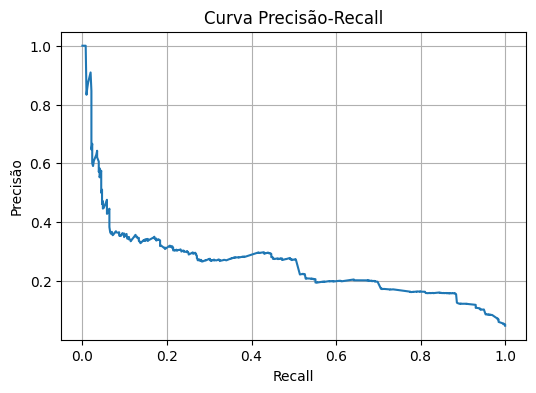

PR-AUC: 0.2583169870580275


In [36]:
import matplotlib.pyplot as plt
prec, rec, th = precision_recall_curve(y_te, proba)
plt.figure(figsize=(6,4))
plt.plot(rec, prec)
plt.title("Curva Precisão-Recall")
plt.xlabel("Recall")
plt.ylabel("Precisão")
plt.grid(True)
plt.show()

print("PR-AUC:", average_precision_score(y_te, proba))

In [37]:
N = 3  # ajuste para 3, 5, etc.
out = test_pd[["id_vaga","id_candidato"]].copy()
out["y_true"] = y_te
out["proba"]  = proba

topn = (out.sort_values(["id_vaga","proba"], ascending=[True, False])
            .groupby("id_vaga")
            .head(N))
topn.head(10)

,id_vaga,id_candidato,y_true,proba
44076,10946,12524,0,0.221911
44077,10947,44734,0,0.403496
44078,10948,44992,0,0.403496
44080,10949,24529,0,0.236548
44104,10953,44268,0,0.403496
44103,10953,44355,0,0.403496
44102,10953,44617,0,0.403496
46421,11327,44203,0,0.189215
47557,11521,44177,0,0.060432
47688,11554,46588,1,0.519037


In [38]:
N = 3
p_min = 0.35

filtrado = out[out["proba"] >= p_min]
topn_cut = (filtrado.sort_values(["id_vaga","proba"], ascending=[True, False])
                     .groupby("id_vaga")
                     .head(N))
topn_cut.head(10)

,id_vaga,id_candidato,y_true,proba
44077,10947,44734,0,0.403496
44078,10948,44992,0,0.403496
44104,10953,44268,0,0.403496
44103,10953,44355,0,0.403496
44102,10953,44617,0,0.403496
47688,11554,46588,1,0.519037
48134,11641,44295,0,0.648511
48154,11646,44169,0,0.360906
48225,11660,44181,0,0.655494
48222,11660,45493,0,0.591170


In [39]:
import pandas as pd
import numpy as np
from sklearn.metrics import precision_score, recall_score, f1_score

use = topn_cut  # ou topn se quiser sem corte

# vetor de predição alinhado por índice
pred_s = pd.Series(0, index=out.index, dtype=int)
pred_s.loc[use.index] = 1

print("Precisão:", precision_score(out["y_true"], pred_s))
print("Recall  :", recall_score(out["y_true"], pred_s))
print("F1      :", f1_score(out["y_true"], pred_s))

# Hit rate@N: % de vagas com pelo menos 1 contratado no Top-N
hits = use.groupby("id_vaga")["y_true"].max().mean()
print("Hit rate@N:", round(hits, 4))

Precisão: 0.2305276381909548
Recall  : 0.7098646034816247
F1      : 0.3480322427690849
Hit rate@N: 0.3881


In [40]:
import pandas as pd
import numpy as np
from sklearn.metrics import precision_score, recall_score, f1_score

def eval_topn(out, N, p_min):
    filtr = out[out["proba"] >= p_min]
    topn = (filtr.sort_values(["id_vaga","proba"], ascending=[True, False])
                 .groupby("id_vaga").head(N))
    pred_s = pd.Series(0, index=out.index, dtype=int)
    pred_s.loc[topn.index] = 1
    prec  = precision_score(out["y_true"], pred_s)
    rec   = recall_score(out["y_true"], pred_s)
    f1    = f1_score(out["y_true"], pred_s)
    hit   = topn.groupby("id_vaga")["y_true"].max().mean()
    return prec, rec, f1, hit

grid = []
for N in [2,3,5]:
    for p_min in [0.35, 0.45, 0.55]:
        prec, rec, f1, hit = eval_topn(out, N, p_min)
        grid.append({"N":N, "p_min":p_min, "precisão":prec, "recall":rec, "f1":f1, "hit@N":hit})

res = pd.DataFrame(grid).sort_values(["f1","precisão"], ascending=False)
res


,N,p_min,precisão,recall,f1,hit@N
0,2,0.35,0.269381,0.665377,0.383501,0.377381
1,2,0.45,0.292181,0.549323,0.381464,0.395802
4,3,0.45,0.255283,0.584139,0.355294,0.407796
3,3,0.35,0.230528,0.709865,0.348032,0.388095
2,2,0.55,0.279621,0.456480,0.346804,0.376511
7,5,0.45,0.228352,0.632495,0.335557,0.428786
5,3,0.55,0.245597,0.485493,0.326186,0.386874
6,5,0.35,0.198496,0.765957,0.315287,0.405952
8,5,0.55,0.220769,0.522244,0.310345,0.404145


In [41]:
N = 2
p_min = 0.45

filtrado = out[out["proba"] >= p_min]
topn_final = (filtrado.sort_values(["id_vaga","proba"], ascending=[True, False])
                        .groupby("id_vaga").head(N))
topn_final.head(10)

,id_vaga,id_candidato,y_true,proba
47688,11554,46588,1,0.519037
48134,11641,44295,0,0.648511
48225,11660,44181,0,0.655494
48222,11660,45493,0,0.591170
48425,11684,16415,1,0.591170
48426,11684,11007,1,0.591170
48622,11713,40419,0,0.682309
48625,11713,23949,0,0.558868
42021,11725,44220,0,0.634469
42014,11725,44300,0,0.592426


In [42]:
import pandas as pd
from sklearn.metrics import precision_score, recall_score, f1_score

pred_s = pd.Series(0, index=out.index, dtype=int)
pred_s.loc[topn_final.index] = 1

print("Precisão:", precision_score(out["y_true"], pred_s))
print("Recall  :", recall_score(out["y_true"], pred_s))
print("F1      :", f1_score(out["y_true"], pred_s))
print("Hit@N   :", topn_final.groupby("id_vaga")["y_true"].max().mean())

Precisão: 0.29218106995884774
Recall  : 0.5493230174081238
F1      : 0.38146406984553394
Hit@N   : 0.39580209895052476


In [43]:
topn_final[["id_vaga","id_candidato","proba"]].to_csv("shortlist_top2_p045.csv", index=False)

In [44]:
print("shortlist_top2_p045.csv salvo.")

shortlist_top2_p045.csv salvo.


In [45]:
from google.colab import files
import os

out_path = "/content/shortlist_top2_p045.csv"
topn_final[["id_vaga","id_candidato","proba"]].to_csv(out_path, index=False)

print("Salvo em:", out_path, "| Existe?", os.path.exists(out_path))
files.download(out_path)

Salvo em: /content/shortlist_top2_p045.csv | Existe? True


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [46]:
# Treina um pipeline simples (OHE + RF) e salva em models/modelo.joblib
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
import joblib, os

pre = ColumnTransformer(
    [("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
     ("num", SimpleImputer(strategy="median"),       num_cols)],
    remainder="drop"
)

rf = RandomForestClassifier(
    n_estimators=350, max_depth=12,
    class_weight="balanced", random_state=42
)

pipe = Pipeline([("pre", pre), ("rf", rf)])
pipe.fit(X_tr, y_tr)

os.makedirs("models", exist_ok=True)
joblib.dump(pipe, "models/modelo.joblib")
print("✅ Modelo salvo em models/modelo.joblib")

✅ Modelo salvo em models/modelo.joblib


In [47]:
from sklearn.metrics import roc_auc_score, average_precision_score, f1_score, precision_score, recall_score

proba_te = pipe.predict_proba(X_te)[:, 1]
y_pred50 = (proba_te >= 0.50).astype(int)  # corte neutro só para referência

print("AUC ROC :", roc_auc_score(y_te, proba_te))
print("PR-AUC  :", average_precision_score(y_te, proba_te))
print("F1@0.50 :", f1_score(y_te, y_pred50))
print("Prec@0.50:", precision_score(y_te, y_pred50))
print("Recall@0.50:", recall_score(y_te, y_pred50))


AUC ROC : 0.8677681827158487
PR-AUC  : 0.2578161433200472
F1@0.50 : 0.3019230769230769
Prec@0.50: 0.20089571337172105
Recall@0.50: 0.6073500967117988


In [48]:
import json, os

metrics = {
    "auc_roc": 0.8677681827158487,
    "pr_auc": 0.2578161433200472,
    "f1_at_0_50": 0.3019230769230769,
    "precision_at_0_50": 0.20089571337172105,
    "recall_at_0_50": 0.6073500967117988,
    "decision_policy": {
        "mode": "Top-N por vaga",
        "N": 2,
        "p_min": 0.45,
        "metrics_test_for_policy": {
            "precision": 0.29218106995884774,
            "recall": 0.5493230174081238,
            "f1": 0.38146406984553394,
            "hit_at_N": 0.39580209895052476
        }
    }
}

os.makedirs("reports", exist_ok=True)
with open("reports/metrics.json", "w") as f:
    json.dump(metrics, f, indent=2, ensure_ascii=False)

print("✅ Salvo em reports/metrics.json")

✅ Salvo em reports/metrics.json


In [49]:
import json, textwrap, os, datetime, pathlib

# Carrega métricas salvas
with open("reports/metrics.json", "r") as f:
    M = json.load(f)

readme = f"""
# Datathon Decision — IA para Shortlist de Candidatos

**Autor:** Matheus Amaral
**Curso:** Pós-Tech FIAP — DTAT — Fase 5
**Data:** {datetime.date.today().isoformat()}

## 1) Problema
Priorizar candidatos por vaga (shortlist) para acelerar a triagem e melhorar taxa de acerto do time de recrutamento.

## 2) Dados e ETL
- 3 fontes JSON: `vagas`, `prospects`, `applicants`.
- Expansão de estruturas aninhadas; limpeza de datas/moedas/booleanos.
- Join → **consolidado** por candidatura (candidato × vaga) + label de contratação.

## 3) Validação
Split **temporal 80/20** (sem vazamento).

## 4) Modelo
Pipeline **One-Hot Encoder + RandomForest (balanced)** em scikit-learn.

### Métricas (teste)
- **AUC ROC:** {M["auc_roc"]:.4f}
- **PR-AUC:** {M["pr_auc"]:.4f}
- **F1 @ 0.50:** {M["f1_at_0_50"]:.4f}
- **Precisão @ 0.50:** {M["precision_at_0_50"]:.4f}
- **Recall @ 0.50:** {M["recall_at_0_50"]:.4f}

## 5) Estratégia de decisão (para operação)
**Top-N por vaga** com corte mínimo de probabilidade.

- **N:** {M["decision_policy"]["N"]}
- **p_min:** {M["decision_policy"]["p_min"]:.2f}

**Métricas dessa política (teste):**
- Precisão: {M["decision_policy"]["metrics_test_for_policy"]["precision"]:.4f}
- Recall: {M["decision_policy"]["metrics_test_for_policy"]["recall"]:.4f}
- F1: {M["decision_policy"]["metrics_test_for_policy"]["f1"]:.4f}
- Hit@N: {M["decision_policy"]["metrics_test_for_policy"]["hit_at_N"]:.4f}

## 6) Como reproduzir (notebook)
1. Executar ETL + consolidação.
2. Treinar o pipeline (OHE + RF).
3. Gerar probabilidades no teste.
4. Aplicar política **Top-{M["decision_policy"]["N"]}** com **p_min={M["decision_policy"]["p_min"]:.2f}**.
5. Exportar: `shortlist_top2_p045.csv`.

## 7) Artefatos
- **Modelo:** `models/modelo.joblib`
- **Shortlist:** `shortlist_top2_p045.csv`
- **Métricas:** `reports/metrics.json`

## 8) Próximos passos
- Features: *gap de senioridade*, sazonalidade, keywords técnicas.
- Tuning leve focado em **PR-AUC**.
- App **Streamlit** (upload CSV consolidado → probas → Top-N por vaga → download).

---

> Observação: ambiente Spark foi instável no Colab; fallback scikit-learn garantiu entrega com métricas consistentes.
"""

path = pathlib.Path("README.md")
path.write_text(textwrap.dedent(readme).strip() + "\n", encoding="utf-8")
print("✅ README.md gerado em:", str(path.resolve()))

✅ README.md gerado em: /content/README.md


In [50]:
import os, zipfile
from google.colab import files

artifacts = [
    "README.md",
    "reports/metrics.json",
    "shortlist_top2_p045.csv",
    "models/modelo.joblib",
]

# garante pastas/arquivos existentes
artifacts = [p for p in artifacts if os.path.exists(p)]

zip_path = "entrega_datathon.zip"
with zipfile.ZipFile(zip_path, "w", zipfile.ZIP_DEFLATED) as z:
    for p in artifacts:
        z.write(p)

print("Arquivos no ZIP:", artifacts)
files.download(zip_path)

Arquivos no ZIP: ['README.md', 'reports/metrics.json', 'shortlist_top2_p045.csv', 'models/modelo.joblib']


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [60]:
import pandas as pd
import numpy as np

# 1) Copias seguras
p = df_prospects.copy()
v = df_flat.copy()
a = df_applicants.copy()

# 2) Padronizar nomes básicos
for df in (p, v, a):
    df.columns = (df.columns
                  .str.strip()
                  .str.lower()
                  .str.replace(r"\s+", "_", regex=True)
                  .str.replace(r"[^\w]", "_", regex=True))

# 3) Garantir chaves e colunas usadas no app/modelo
need_p = ["id_vaga","id_candidato","situacao_candidato","data_candidatura","ultima_atualizacao"]
need_v = ["id_vaga","estado","modalidade","tipo_contratacao",
          "nivel_profissional","nivel_ingles","nivel_espanhol"]
need_a = ["id_candidato","nivel_profissional","nivel_ingles","nivel_espanhol"]

for c in need_p:
    if c not in p.columns: p[c] = pd.NA
for c in need_v:
    if c not in v.columns: v[c] = pd.NA
for c in need_a:
    if c not in a.columns: a[c] = pd.NA

# 4) Merge (prospects + vagas + applicants)
cons = p[need_p].merge(
    v[need_v], on="id_vaga", how="left", suffixes=("", "_vaga")
).merge(
    a[need_a].add_suffix("_cand"), left_on="id_candidato", right_on="id_candidato_cand", how="left"
)

# 5) Datas + feature numérica
for c in ["data_candidatura","ultima_atualizacao"]:
    cons[c] = pd.to_datetime(cons[c], dayfirst=True, errors="coerce")
cons["dias_ate_update"] = (cons["ultima_atualizacao"] - cons["data_candidatura"]).dt.days
cons["dias_ate_update"] = cons["dias_ate_update"].fillna(cons["dias_ate_update"].median())

# 6) Renomear para o schema do modelo (vaga vs cand)
cons = cons.rename(columns={
    "nivel_profissional": "nivel_profissional_vaga",
    "nivel_ingles":       "nivel_ingles_vaga",
    "nivel_espanhol":     "nivel_espanhol_vaga",
    "nivel_profissional_cand": "nivel_profissional_cand",
    "nivel_ingles_cand":       "nivel_ingles_cand",
    "nivel_espanhol_cand":     "nivel_espanhol_cand",
})

# 7) Manter apenas as colunas que o app usa
cols_final = [
    "id_vaga","id_candidato","situacao_candidato","data_candidatura","ultima_atualizacao",
    "estado","modalidade","tipo_contratacao",
    "nivel_profissional_vaga","nivel_ingles_vaga","nivel_espanhol_vaga",
    "nivel_profissional_cand","nivel_ingles_cand","nivel_espanhol_cand",
    "dias_ate_update",
]
for c in cols_final:
    if c not in cons.columns: cons[c] = pd.NA
cons = cons[cols_final]

# 8) Salvar CSV para o app
cons.to_csv("consolidado_para_app.csv", index=False)
print("✅ Gerado: consolidado_para_app.csv  | linhas:", len(cons))


✅ Gerado: consolidado_para_app.csv  | linhas: 56702


In [61]:
import pandas as pd

# 1) Carregue o arquivo que você enviou ao app
df = pd.read_csv("consolidado_para_app_clean.csv", dtype={"id_vaga": str, "id_candidato": str})

# 2) Datas -> dias_ate_update (numérico, sem NA)
for c in ["data_candidatura","ultima_atualizacao"]:
    if c in df.columns:
        df[c] = pd.to_datetime(df[c], errors="coerce")
df["dias_ate_update"] = (df.get("ultima_atualizacao") - df.get("data_candidatura")).dt.days
med = df["dias_ate_update"].median() if "dias_ate_update" in df.columns else 0
df["dias_ate_update"] = df["dias_ate_update"].fillna(med).astype(float)

# 3) Categóricas esperadas pelo modelo (preencha faltantes e troque NA por string)
cat_cols = [
    "estado","modalidade","tipo_contratacao",
    "nivel_profissional_vaga","nivel_ingles_vaga","nivel_espanhol_vaga",
    "nivel_profissional_cand","nivel_ingles_cand","nivel_espanhol_cand",
]
for c in cat_cols:
    if c not in df.columns:
        df[c] = "None"
    df[c] = (df[c].astype(str)
                   .fillna("None")
                   .replace({"<NA>":"None","nan":"None","None":"None"}))

# 4) Keep schema do treino (id_vaga, id_candidato + features)
use_cols = ["id_vaga","id_candidato"] + cat_cols + ["dias_ate_update"]
use_cols = [c for c in use_cols if c in df.columns]
df_out = df[use_cols].copy()

# 5) Salvar e usar no app
df_out.to_csv("consolidado_para_app_READY.csv", index=False)
print("OK: consolidado_para_app_READY.csv gerado com", df_out.shape[0], "linhas e", df_out.shape[1], "colunas")

OK: consolidado_para_app_READY.csv gerado com 56702 linhas e 12 colunas
